Regularization is the technique to reduce overfitting in regression. Overfitting is the condition where a model performs exceptionally well on the training data  
Three types of regularization:
1. Ridge (L2)
2. Lasso (L1)
3. Elastic Net 

In case of Overflitting we must decrease the slope of the line to some extent such that it performs well on testing data rather than performing exceptionally well on training data

L = summation(yi - yi hat)^2 is the loss function.. we have to add a term which is lambda(hyperparameter)* m^2 which reduces the slope of the function
whose value ranges from 0-infinity 
Since, we use squaring of slope to reduce the variance lambda (m1^2 + m2^2 + m3^2 + mn^2)
So, it is known as L2 norm... so, it is called L2 regularization...

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
X = data.data
y = data.target

In [4]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2 , random_state=42)

In [5]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [6]:
lr.fit(x_train , y_train)
y_pred = lr.predict(x_test)

In [7]:
from sklearn.metrics import r2_score, mean_squared_error
print("R2 score: ",r2_score(y_test, y_pred))
print("MSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 score:  0.4526027629719197
MSE:  53.85344583676592


In [8]:
from sklearn.linear_model import Ridge

R = Ridge(alpha = 0.001) #alpha is the hyperparamter lambda of the ridge regression which is multiplied with the square of mean

In [9]:
R.fit(x_train, y_train)
y_pred1 = R.predict(x_test)

In [10]:
print("R2 score: ",r2_score(y_test, y_pred1))
print("MSE: ", np.sqrt(mean_squared_error(y_test, y_pred1)))

R2 score:  0.453428030101933
MSE:  53.812835253363176


In [11]:
m = 100
x1 = 5 * np.random.rand(m,1) - 2 #rand generates 100 different random numbers based on the range.. In this case, it ranges between 0 and 1 
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m,1) # randn generates normal data between -1 and 1 such that every x1 has a x2 and x2 is a polynomial regression model... such that it has 2nd power of x1

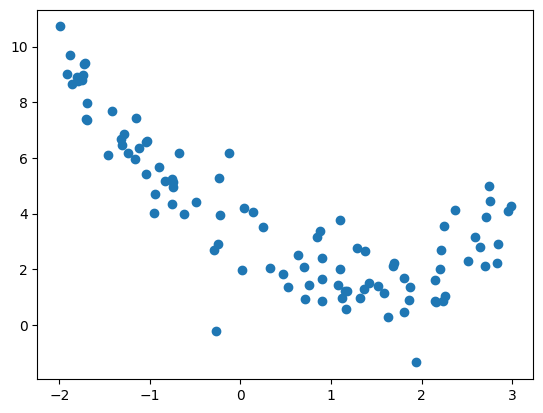

In [12]:
plt.scatter(x1,x2)
plt.show()

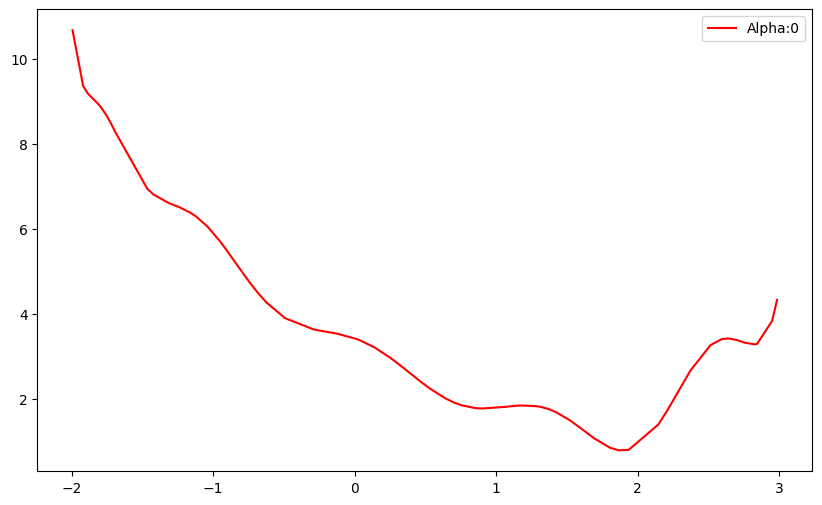

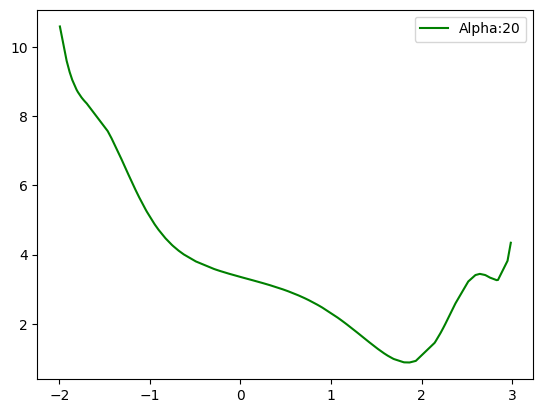

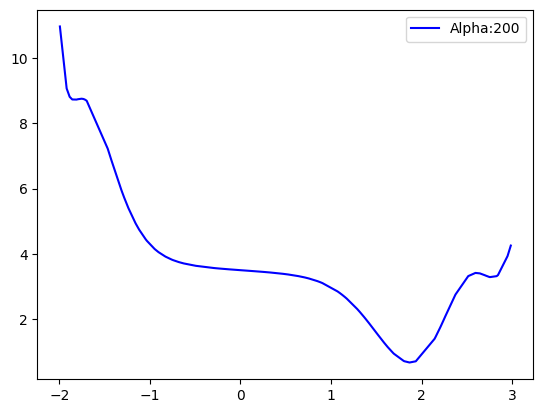

"Here 'Alpha:{}' is a string template with a placeholder {}.\n.format(alpha) replaces {} with the current value of alpha. "

In [14]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([('poly_feats', PolynomialFeatures(degree = 16)),
                      ('ridge', Ridge(alpha = alpha))])
    model.fit(x1,x2)
    return model.predict(x1)

alphas = [0,20,200]
cs = ['r','g','b']

plt.figure(figsize=(10,6))
# plt.plot(x1,x2,"b+", label= "Datapoints")

for alpha, c in zip(alphas,cs): #zip() combines two (or more) lists into pairs element by element.
    preds = get_preds_ridge(x1,x2,alpha)
    plt.plot(sorted(x1[:,0]), preds[np.argsort(x1[:,0])], c, label = 'Alpha:{}'.format(alpha)) #argsort returns the list of indices of the x1 and according to that y is also sorted making the same pairs as x before sort
    plt.legend()
    plt.show()

'''Here 'Alpha:{}' is a string template with a placeholder {}.
.format(alpha) replaces {} with the current value of alpha. '''
